In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import wordcloud as wc

In [2]:
df = pd.read_csv("ecommerce_data.csv")

In [3]:
df.head()

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,top_category_bought,avg_rating_given,total_sessions,preferred_device_sess,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,55+,2020-09-04,True,2,115.39,...,Beauty,3.00,5,desktop,email,2022-03-18T01:58:29,2025-06-25T14:09:53,0,low,1
1,2,Phillip Ramos,christinarubio@example.com,IN,26,25-34,2020-04-05,False,2,68.52,...,Sports,NaN,3,mobile,organic,2021-06-09T11:10:13,2025-01-02T01:01:29,0,low,1
2,3,Dawn Fowler,jessica03@example.org,BR,21,18-24,2023-08-31,True,1,66.72,...,Electronics,NaN,5,mobile,direct,2020-07-04T06:53:11,2025-08-28T11:01:14,0,low,0
3,4,Mario Butler,paula27@example.org,FR,63,55+,2022-06-30,True,2,279.86,...,Beauty,NaN,9,desktop,direct,2020-09-29T02:46:16,2024-11-27T23:38:49,0,medium,1
4,5,Amber Brown,kevin85@example.net,BR,19,18-24,2022-07-22,True,3,271.29,...,Beauty,3.67,9,desktop,organic,2020-01-31T02:47:48,2025-01-29T23:45:28,0,medium,1


In [4]:
df.shape

(20000, 27)

In [5]:
df.isna().sum()

customer_id                  0
name                         0
email                        0
country                      0
age                          0
age_group                    0
signup_date                  0
marketing_opt_in             0
total_orders                 0
total_spend_usd              0
avg_order_value              0
avg_discount_pct             0
first_order_date          3732
last_order_date           3732
preferred_payment         3732
preferred_device_ord      3732
preferred_source          3732
top_category_bought       3732
avg_rating_given         14741
total_sessions               0
preferred_device_sess       55
preferred_source_sess       55
first_session_date          55
last_session_date           55
has_abandoned_cart           0
clv_tier                     0
is_repeat_customer           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df[df["total_orders"] == 0].isnull().sum()

customer_id                 0
name                        0
email                       0
country                     0
age                         0
age_group                   0
signup_date                 0
marketing_opt_in            0
total_orders                0
total_spend_usd             0
avg_order_value             0
avg_discount_pct            0
first_order_date         3732
last_order_date          3732
preferred_payment        3732
preferred_device_ord     3732
preferred_source         3732
top_category_bought      3732
avg_rating_given         3732
total_sessions              0
preferred_device_sess      55
preferred_source_sess      55
first_session_date         55
last_session_date          55
has_abandoned_cart          0
clv_tier                    0
is_repeat_customer          0
dtype: int64

## Create Customer Segments

In [8]:
df["customer_segment"] = "Buyer"

df.loc[df["total_orders"] == 0, "customer_segment"] = "Non-Buyer"

df.loc[
    (df["total_orders"] == 0) &
    (df["total_sessions"] == 0),
    "customer_segment"
] = "Inactive User"

In [9]:
df["customer_segment"].value_counts()

customer_segment
Buyer            16268
Non-Buyer         3677
Inactive User       55
Name: count, dtype: int64

In [10]:
purchase_cols = [
    "preferred_payment",
    "preferred_device_ord",
    "preferred_source",
    "top_category_bought"
]

df[purchase_cols] = df[purchase_cols].fillna("No Purchase")

In [11]:
session_cols = [
    "preferred_device_sess",
    "preferred_source_sess"
]

df[session_cols] = df[session_cols].fillna("No Session")

In [12]:
df.isna().sum()

customer_id                  0
name                         0
email                        0
country                      0
age                          0
age_group                    0
signup_date                  0
marketing_opt_in             0
total_orders                 0
total_spend_usd              0
avg_order_value              0
avg_discount_pct             0
first_order_date          3732
last_order_date           3732
preferred_payment            0
preferred_device_ord         0
preferred_source             0
top_category_bought          0
avg_rating_given         14741
total_sessions               0
preferred_device_sess        0
preferred_source_sess        0
first_session_date          55
last_session_date           55
has_abandoned_cart           0
clv_tier                     0
is_repeat_customer           0
customer_segment             0
dtype: int64

In [13]:
df.loc[
    (df["total_orders"] > 0) &
    (df["avg_rating_given"].isnull()),
    "avg_rating_given"
] = 0

In [14]:
df["rating_status"] = "Rated"

df.loc[df["avg_rating_given"].isnull(), "rating_status"] = "No Purchase"

df.loc[
    (df["total_orders"] > 0) &
    (df["avg_rating_given"] == 0),
    "rating_status"
] = "No Rating Given"

In [15]:
df.isna().sum()

customer_id                 0
name                        0
email                       0
country                     0
age                         0
age_group                   0
signup_date                 0
marketing_opt_in            0
total_orders                0
total_spend_usd             0
avg_order_value             0
avg_discount_pct            0
first_order_date         3732
last_order_date          3732
preferred_payment           0
preferred_device_ord        0
preferred_source            0
top_category_bought         0
avg_rating_given         3732
total_sessions              0
preferred_device_sess       0
preferred_source_sess       0
first_session_date         55
last_session_date          55
has_abandoned_cart          0
clv_tier                    0
is_repeat_customer          0
customer_segment            0
rating_status               0
dtype: int64

In [16]:
df

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,total_sessions,preferred_device_sess,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer,customer_segment,rating_status
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,55+,2020-09-04,True,2,115.39,...,5,desktop,email,2022-03-18T01:58:29,2025-06-25T14:09:53,0,low,1,Buyer,Rated
1,2,Phillip Ramos,christinarubio@example.com,IN,26,25-34,2020-04-05,False,2,68.52,...,3,mobile,organic,2021-06-09T11:10:13,2025-01-02T01:01:29,0,low,1,Buyer,No Rating Given
2,3,Dawn Fowler,jessica03@example.org,BR,21,18-24,2023-08-31,True,1,66.72,...,5,mobile,direct,2020-07-04T06:53:11,2025-08-28T11:01:14,0,low,0,Buyer,No Rating Given
3,4,Mario Butler,paula27@example.org,FR,63,55+,2022-06-30,True,2,279.86,...,9,desktop,direct,2020-09-29T02:46:16,2024-11-27T23:38:49,0,medium,1,Buyer,No Rating Given
4,5,Amber Brown,kevin85@example.net,BR,19,18-24,2022-07-22,True,3,271.29,...,9,desktop,organic,2020-01-31T02:47:48,2025-01-29T23:45:28,0,medium,1,Buyer,Rated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,Leroy Proctor,hannah36@example.net,GB,28,25-34,2025-04-28,True,1,65.53,...,2,mobile,paid,2021-04-04T08:08:51,2022-04-02T17:51:19,0,low,0,Buyer,No Rating Given
19996,19997,Stephanie Murphy MD,kristina47@example.org,US,64,55+,2022-06-22,False,0,0.00,...,4,desktop,social,2021-04-05T11:28:26,2024-02-05T18:58:58,1,no_purchase,0,Non-Buyer,No Purchase
19997,19998,David Lara,erik91@example.com,BR,23,18-24,2020-08-30,True,4,568.55,...,9,desktop,direct,2020-12-09T07:19:37,2025-03-04T05:34:33,0,medium,1,Buyer,Rated
19998,19999,Erik Mitchell,warrenvictoria@example.org,CA,25,25-34,2024-09-16,False,2,57.36,...,7,mobile,direct,2021-10-26T14:30:30,2025-10-24T01:40:32,0,low,1,Buyer,Rated


In [17]:
df["age_group"].value_counts()

age_group
55+      7243
25-34    3498
45-54    3445
35-44    3400
18-24    2414
Name: count, dtype: int64

In [18]:
df["rating_status"].value_counts()

rating_status
No Rating Given    11009
Rated               5259
No Purchase         3732
Name: count, dtype: int64

In [19]:
df.head()

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,total_sessions,preferred_device_sess,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer,customer_segment,rating_status
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,55+,2020-09-04,True,2,115.39,...,5,desktop,email,2022-03-18T01:58:29,2025-06-25T14:09:53,0,low,1,Buyer,Rated
1,2,Phillip Ramos,christinarubio@example.com,IN,26,25-34,2020-04-05,False,2,68.52,...,3,mobile,organic,2021-06-09T11:10:13,2025-01-02T01:01:29,0,low,1,Buyer,No Rating Given
2,3,Dawn Fowler,jessica03@example.org,BR,21,18-24,2023-08-31,True,1,66.72,...,5,mobile,direct,2020-07-04T06:53:11,2025-08-28T11:01:14,0,low,0,Buyer,No Rating Given
3,4,Mario Butler,paula27@example.org,FR,63,55+,2022-06-30,True,2,279.86,...,9,desktop,direct,2020-09-29T02:46:16,2024-11-27T23:38:49,0,medium,1,Buyer,No Rating Given
4,5,Amber Brown,kevin85@example.net,BR,19,18-24,2022-07-22,True,3,271.29,...,9,desktop,organic,2020-01-31T02:47:48,2025-01-29T23:45:28,0,medium,1,Buyer,Rated


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            20000 non-null  int64  
 1   name                   20000 non-null  object 
 2   email                  20000 non-null  object 
 3   country                20000 non-null  object 
 4   age                    20000 non-null  int64  
 5   age_group              20000 non-null  object 
 6   signup_date            20000 non-null  object 
 7   marketing_opt_in       20000 non-null  bool   
 8   total_orders           20000 non-null  int64  
 9   total_spend_usd        20000 non-null  float64
 10  avg_order_value        20000 non-null  float64
 11  avg_discount_pct       20000 non-null  float64
 12  first_order_date       16268 non-null  object 
 13  last_order_date        16268 non-null  object 
 14  preferred_payment      20000 non-null  object 
 15  pr

In [21]:
date_cols = [
    "signup_date",
    "first_order_date",
    "last_order_date",
    "first_session_date",
    "last_session_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [22]:
df.describe()

,customer_id,age,signup_date,total_orders,total_spend_usd,avg_order_value,avg_discount_pct,first_order_date,last_order_date,avg_rating_given,total_sessions,first_session_date,last_session_date,has_abandoned_cart,is_repeat_customer
count,20000.000000,20000.000000,20000,20000.000000,20000.000000,20000.000000,20000.000000,16268,16268,16268.000000,20000.000000,19945,19945,20000.000000,20000.000000
mean,10000.500000,46.492550,2022-12-07 03:27:38.880000,1.679000,224.660873,109.137204,5.815728,2022-02-21 16:18:37.545242368,2023-09-17 03:14:53.119928832,1.270551,6.000000,2020-12-16 01:47:54.323840512,2024-11-14 22:33:16.375031296,0.183850,0.502250
min,1.000000,18.000000,2020-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,2020-01-01 01:10:58,2020-01-01 07:25:07,0.000000,0.000000,2020-01-01 00:06:58,2020-01-12 17:00:14,0.000000,0.000000
25%,5000.750000,32.000000,2021-06-24 00:00:00,1.000000,32.160000,27.140000,0.000000,2020-10-22 07:12:00,2022-07-28 12:50:26.500000,0.000000,4.000000,2020-04-11 02:43:11,2024-06-28 14:21:58,0.000000,0.000000
50%,10000.500000,46.500000,2022-12-15 00:00:00,2.000000,145.390000,82.580000,5.000000,2021-10-29 21:01:56.500000,2024-01-10 20:53:32.500000,0.000000,6.000000,2020-08-30 00:19:55,2025-03-02 07:36:13,0.000000,1.000000
75%,15000.250000,61.000000,2024-05-21 00:00:00,2.000000,322.400000,151.052500,10.000000,2023-04-08 04:01:18.500000,2025-01-19 19:56:10.249999872,3.330000,8.000000,2021-04-30 10:32:43,2025-07-24 07:36:38,0.000000,1.000000
max,20000.000000,75.000000,2025-10-31 00:00:00,9.000000,3026.420000,2680.640000,20.000000,2025-10-31 22:59:41,2025-10-31 22:59:41,5.000000,17.000000,2025-10-27 02:39:57,2025-10-31 23:34:11,1.000000,1.000000
std,5773.647028,16.767961,NaN,1.292959,262.272901,122.423757,6.025030,NaN,NaN,1.906630,2.468219,NaN,NaN,0.387372,0.500007


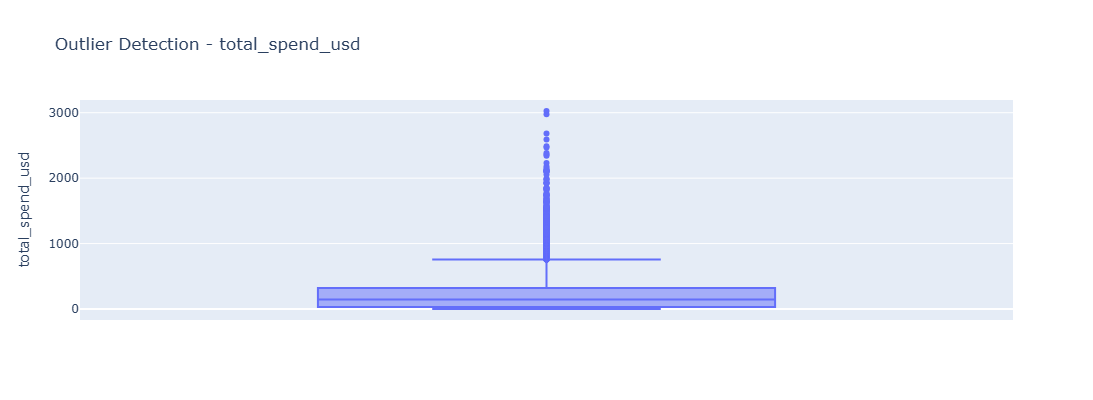

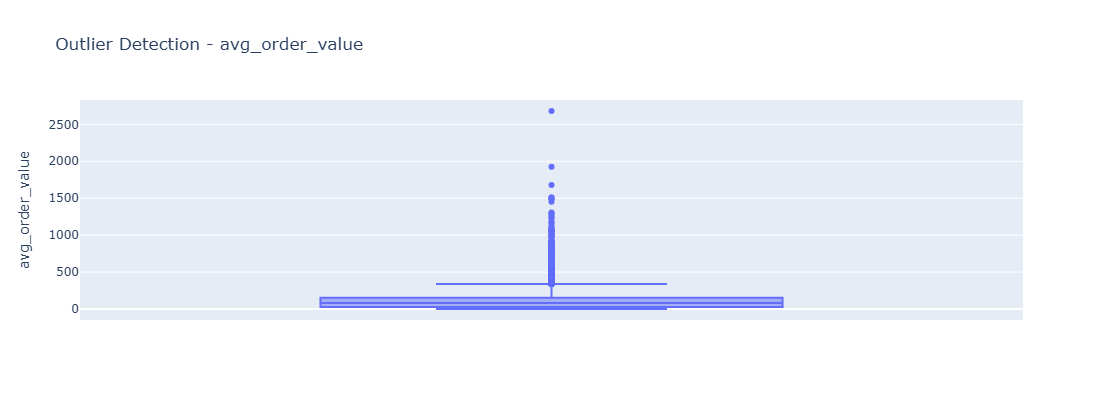

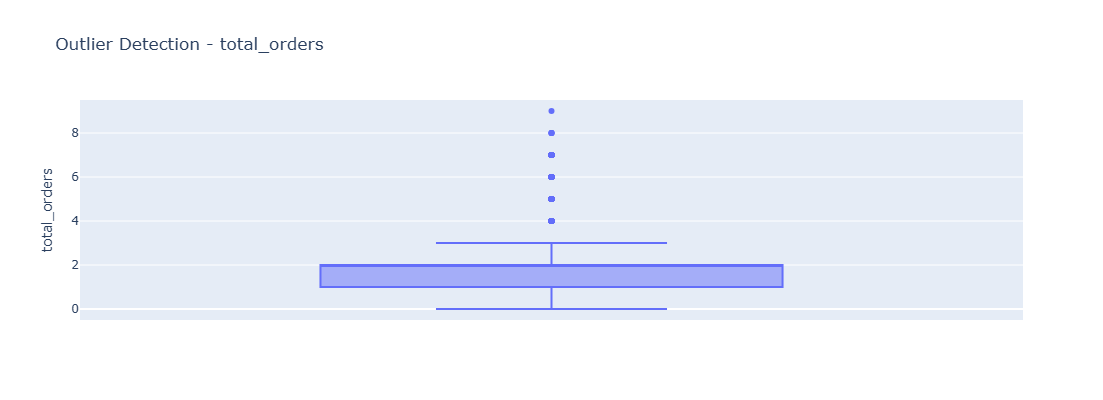

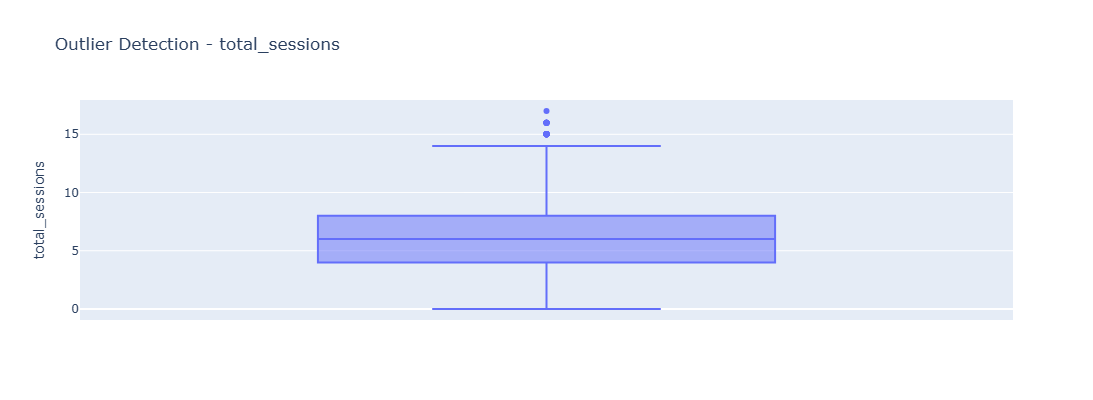

In [23]:
cols = [
    "total_spend_usd",
    "avg_order_value",
    "total_orders",
    "total_sessions"
]

for col in cols:
    fig = px.box(df, y=col, title=f"Outlier Detection - {col}",height=400,width=400)
    fig.show()

In [24]:
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Outliers: {len(outliers)}")
    print("-"*40)

In [25]:
cols = [
    "total_spend_usd",
    "avg_order_value",
    "total_orders",
    "total_sessions"
]

for col in cols:
    detect_outliers(df, col)

total_spend_usd
Lower Bound: -403.1999999999999
Upper Bound: 757.7599999999999
Outliers: 914
----------------------------------------
avg_order_value
Lower Bound: -158.72875
Upper Bound: 336.92125
Outliers: 851
----------------------------------------
total_orders
Lower Bound: -0.5
Upper Bound: 3.5
Outliers: 1770
----------------------------------------
total_sessions
Lower Bound: -2.0
Upper Bound: 14.0
Outliers: 33
----------------------------------------


In [26]:
Q1 = df["total_sessions"].quantile(0.25)
Q3 = df["total_sessions"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["total_sessions"] = df["total_sessions"].clip(lower, upper)

## Basic Dataset Insights

#### Total Customers

In [27]:
df["customer_id"].nunique()

20000

#### Here In our data Total 20,000 Unique Customers.

#### Total Revenue 

In [28]:
revenue = df["total_spend_usd"].sum()
print("Total Revenue Generated : ",revenue)

Total Revenue Generated :  4493217.47


#### Average Order Value

In [29]:
print(df["avg_order_value"].mean())

109.1372045


#### Total Orders

In [30]:
print(df["total_orders"].sum())

33580


#### Buyer vs Non-Buyer Ratio

In [31]:
df["customer_segment"].value_counts()

customer_segment
Buyer            16268
Non-Buyer         3677
Inactive User       55
Name: count, dtype: int64

## Who Are Our Customers?

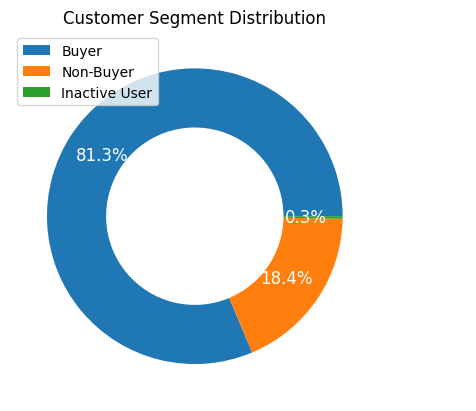

In [32]:
data = df['customer_segment'].value_counts()

plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    pctdistance=0.75,  # Position of percentage text
    textprops={'color':'white', 'fontsize':12},  # Change color & size
    wedgeprops={'width':0.4}
)

plt.title("Customer Segment Distribution")
plt.legend()

plt.show()

## Data Visualization

In [33]:
df.head()

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,total_sessions,preferred_device_sess,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer,customer_segment,rating_status
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,55+,2020-09-04,True,2,115.39,...,5,desktop,email,2022-03-18 01:58:29,2025-06-25 14:09:53,0,low,1,Buyer,Rated
1,2,Phillip Ramos,christinarubio@example.com,IN,26,25-34,2020-04-05,False,2,68.52,...,3,mobile,organic,2021-06-09 11:10:13,2025-01-02 01:01:29,0,low,1,Buyer,No Rating Given
2,3,Dawn Fowler,jessica03@example.org,BR,21,18-24,2023-08-31,True,1,66.72,...,5,mobile,direct,2020-07-04 06:53:11,2025-08-28 11:01:14,0,low,0,Buyer,No Rating Given
3,4,Mario Butler,paula27@example.org,FR,63,55+,2022-06-30,True,2,279.86,...,9,desktop,direct,2020-09-29 02:46:16,2024-11-27 23:38:49,0,medium,1,Buyer,No Rating Given
4,5,Amber Brown,kevin85@example.net,BR,19,18-24,2022-07-22,True,3,271.29,...,9,desktop,organic,2020-01-31 02:47:48,2025-01-29 23:45:28,0,medium,1,Buyer,Rated


In [34]:
country_map = {
    'US': 'United States',
    'IN': 'India',
    'GB': 'United Kingdom',
    'BR': 'Brazil',
    'DE': 'Germany',
    'FR': 'France',
    'MX': 'Mexico',
    'AU': 'Australia',
    'CA': 'Canada',
    'JP': 'Japan',
    'ES': 'Spain',
    'NL': 'Netherlands',
    'SG': 'Singapore',
    'SE': 'Sweden',
    'PL': 'Poland',
    'AE': 'United Arab Emirates',
    'ZA': 'South Africa'
}

df['country'] = df['country'].replace(country_map)

data = df['country'].value_counts()

In [35]:
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

## Where Are Our Customers From ?

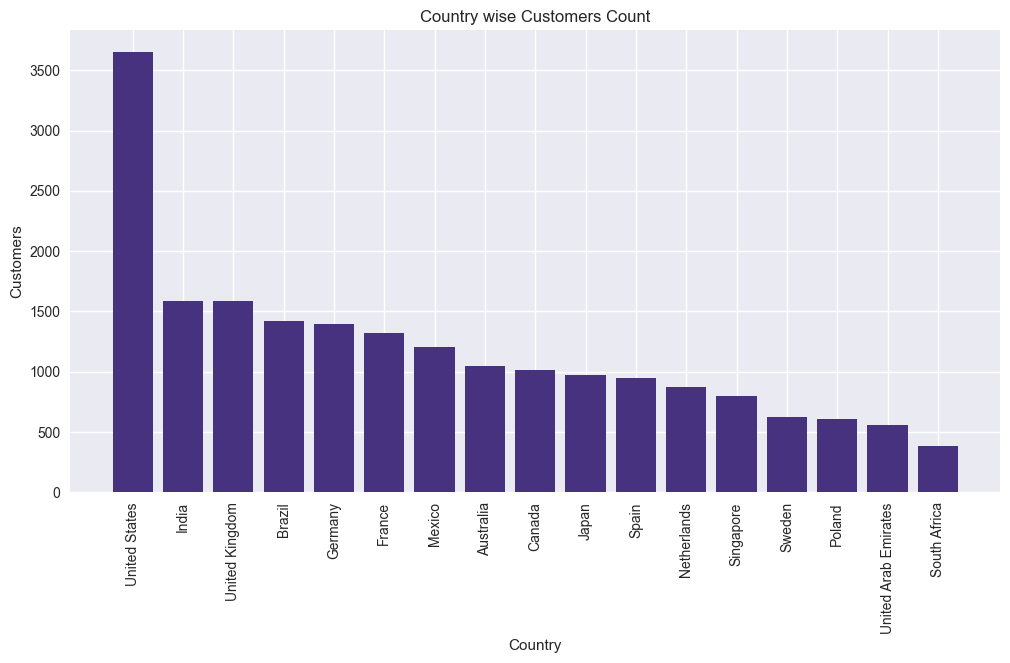

In [36]:
plt.bar(data.index , data.values)
plt.title("Country wise Customers Count")
plt.xlabel("Country")
plt.ylabel("Customers")
plt.xticks(rotation=90)
plt.show()

In [37]:
df.head()

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,total_sessions,preferred_device_sess,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer,customer_segment,rating_status
0,1,Jennifer Salinas,nicholas59@example.org,Japan,71,55+,2020-09-04,True,2,115.39,...,5,desktop,email,2022-03-18 01:58:29,2025-06-25 14:09:53,0,low,1,Buyer,Rated
1,2,Phillip Ramos,christinarubio@example.com,India,26,25-34,2020-04-05,False,2,68.52,...,3,mobile,organic,2021-06-09 11:10:13,2025-01-02 01:01:29,0,low,1,Buyer,No Rating Given
2,3,Dawn Fowler,jessica03@example.org,Brazil,21,18-24,2023-08-31,True,1,66.72,...,5,mobile,direct,2020-07-04 06:53:11,2025-08-28 11:01:14,0,low,0,Buyer,No Rating Given
3,4,Mario Butler,paula27@example.org,France,63,55+,2022-06-30,True,2,279.86,...,9,desktop,direct,2020-09-29 02:46:16,2024-11-27 23:38:49,0,medium,1,Buyer,No Rating Given
4,5,Amber Brown,kevin85@example.net,Brazil,19,18-24,2022-07-22,True,3,271.29,...,9,desktop,organic,2020-01-31 02:47:48,2025-01-29 23:45:28,0,medium,1,Buyer,Rated


## Customer Age Groups

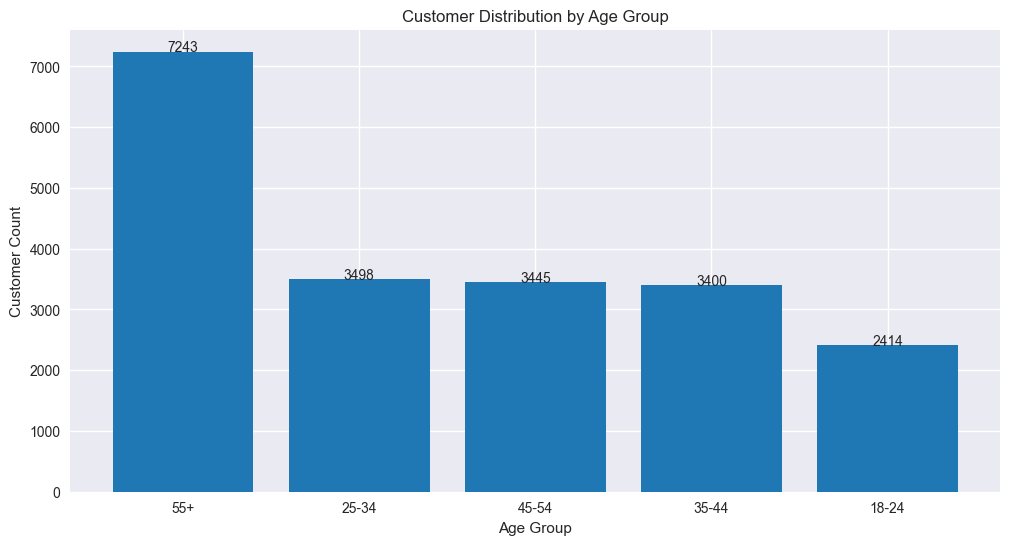

In [38]:

# Count age groups
data = df['age_group'].value_counts()

# Bar plot
plt.bar(data.index,data.values,color='#1f77b4')
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Customer Count")
for i, v in enumerate(data.values):
    plt.text(i, v, str(v), ha='center')

plt.show()

### Age Group Distribution Insight

The analysis shows that the **55+ age group has the highest customer count (7,243)**, indicating strong platform adoption among older users. In contrast, the **18–24 age group has the lowest representation (2,414)**, highlighting an opportunity to attract younger customers through targeted marketing strategies and an improved mobile-first shopping experience.

### Highest Spending Age Group

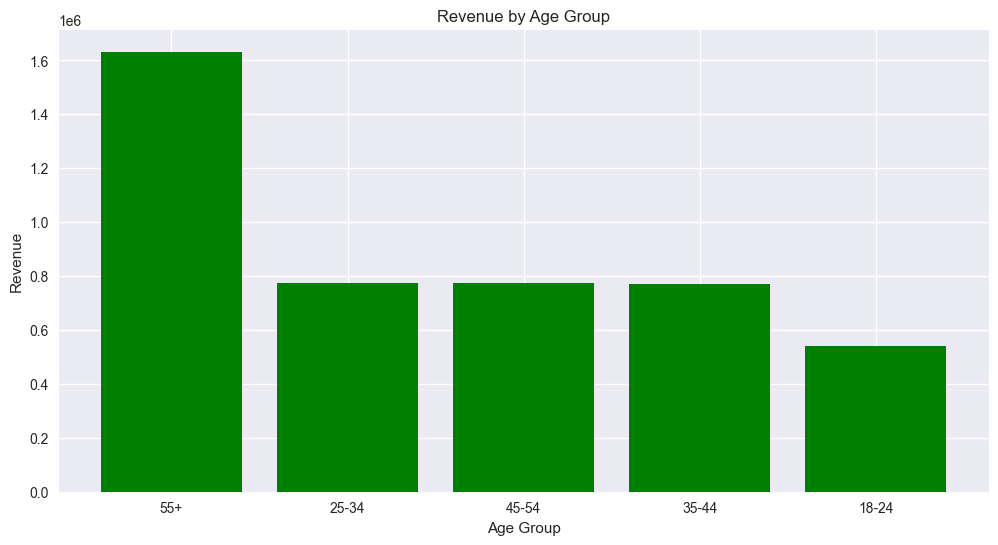

In [39]:
age_spend = df.groupby("age_group")["total_spend_usd"].sum().sort_values(ascending=False)

plt.bar(age_spend.index,age_spend.values,color="green")

plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.title("Revenue by Age Group")
plt.show()

In [40]:
data = df.groupby("country")["total_spend_usd"].sum().sort_values(ascending=False)

## Country wise Customers Spends

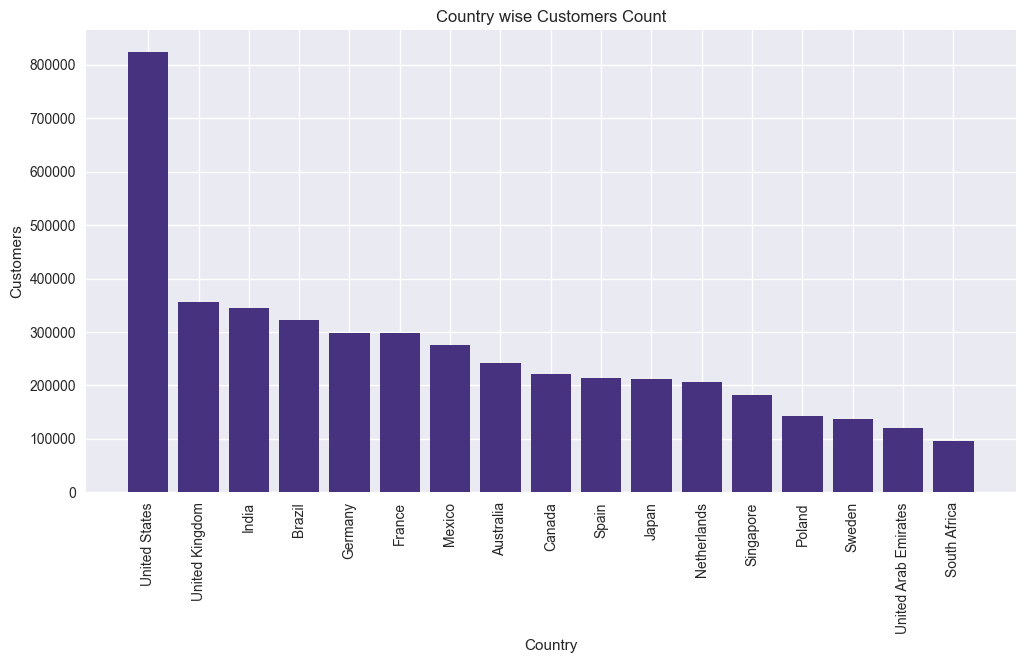

In [41]:
plt.bar(data.index , data.values)
plt.title("Country wise Customers Spends")
plt.xlabel("Country")
plt.ylabel("Customers Spends")
plt.xticks(rotation=90)
plt.show()

## Revenue Distribution

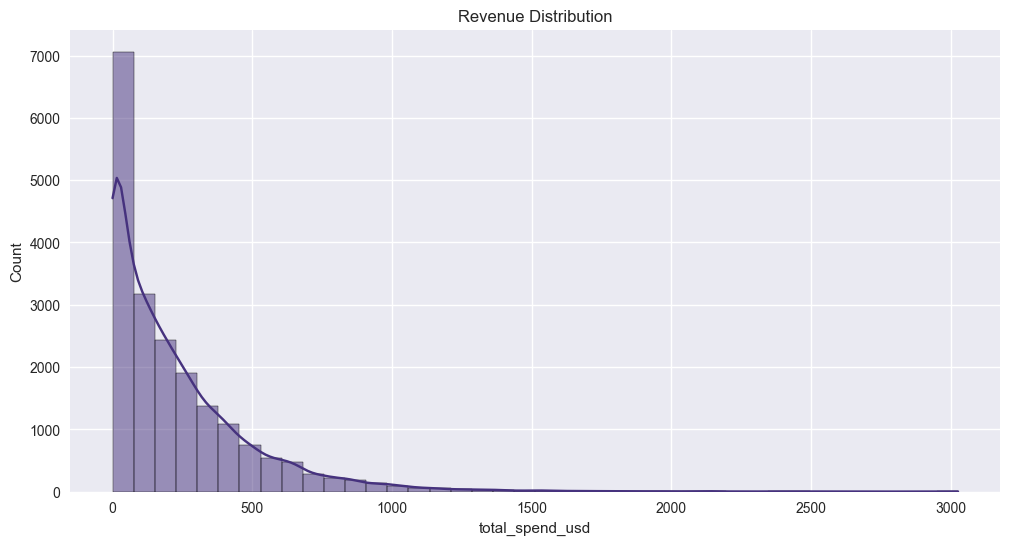

In [42]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["total_spend_usd"],
    bins=40,
    kde=True
)

plt.title("Revenue Distribution")

plt.show()

## Top Product Categories

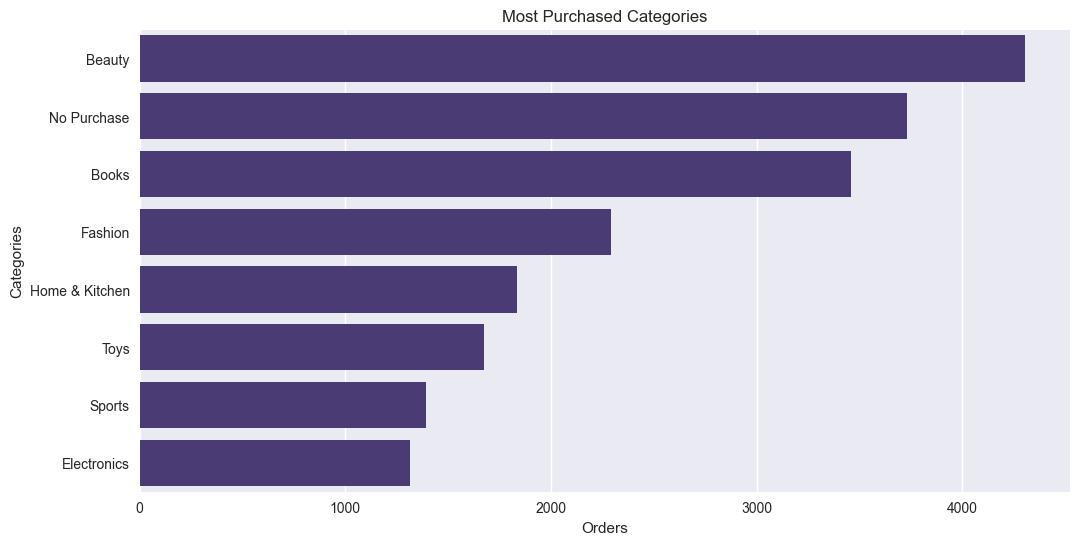

In [43]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="top_category_bought",
    data=df,
    order=df["top_category_bought"].value_counts().index
)
plt.xlabel("Orders")
plt.ylabel("Categories")
plt.title("Most Purchased Categories")

plt.show()

## Revenue by Category

In [44]:
data = df.groupby("top_category_bought")["total_spend_usd"].sum().sort_values()
data

top_category_bought
No Purchase             0.00
Toys               289669.84
Sports             431079.88
Electronics        533578.90
Home & Kitchen     538688.35
Fashion            689488.56
Books              745799.92
Beauty            1264912.02
Name: total_spend_usd, dtype: float64

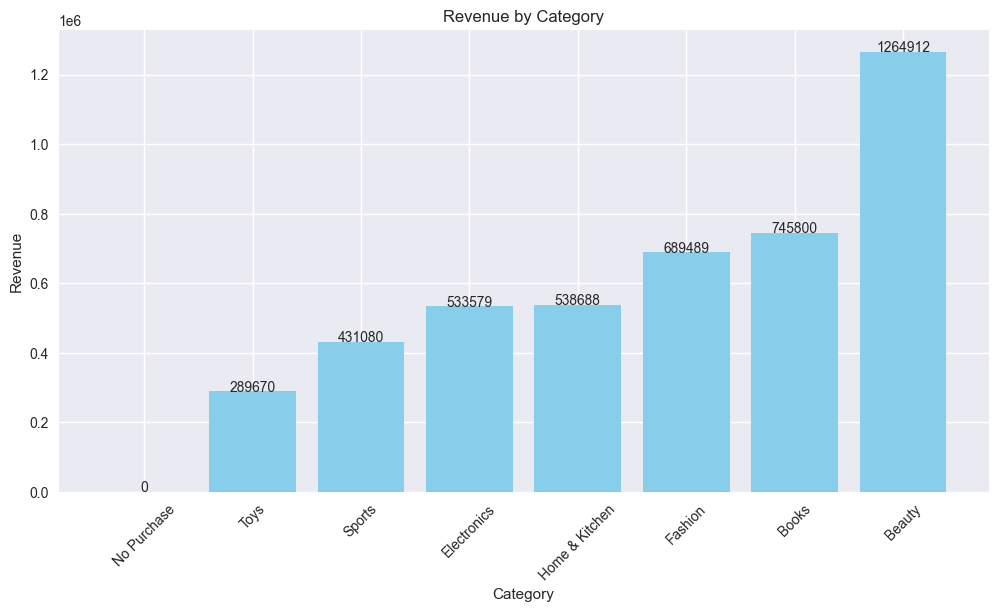

In [45]:
data = df.groupby("top_category_bought")["total_spend_usd"].sum().sort_values()

plt.bar(
    data.index,
    data.values,
    color='skyblue'
)

# Add text on bars
for i, v in enumerate(data.values):
    plt.text(i, v, f"{v:.0f}", ha='center')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Payment Method Analysis

In [46]:
df["preferred_payment"] = df["preferred_payment"].str.capitalize()

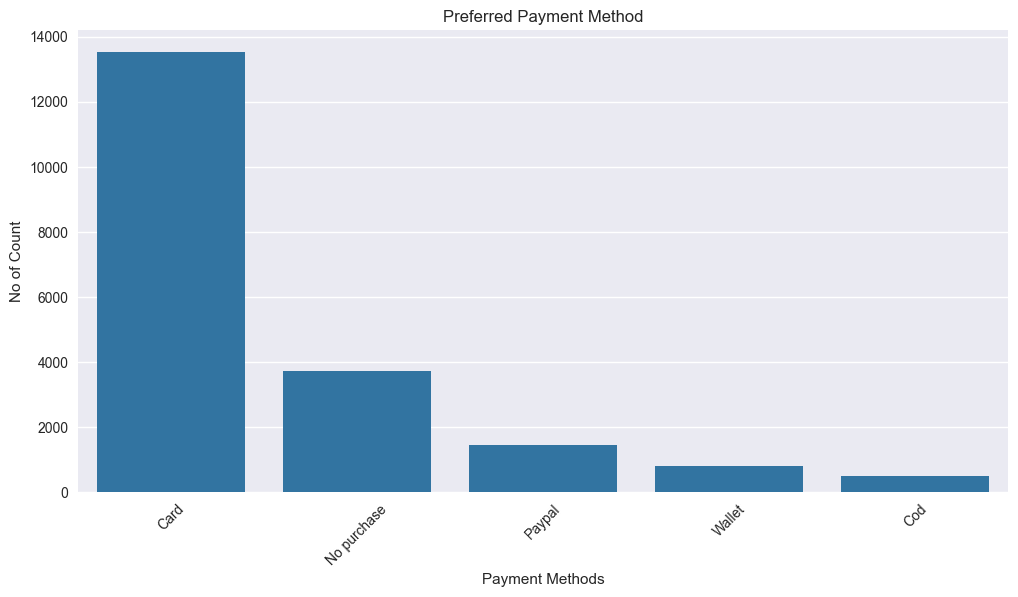

In [47]:
order = df["preferred_payment"].value_counts().index

sns.countplot(
    x="preferred_payment",
    data=df,
    order=order,
    color="#1f77b4"
)

plt.title("Preferred Payment Method")
plt.xlabel("Payment Methods")
plt.ylabel("No of Count")
plt.xticks(rotation=45)

plt.show()

In [48]:
df["preferred_device_ord"] = df["preferred_device_ord"].str.capitalize()

In [49]:
df["preferred_device_ord"].value_counts().index

Index(['Mobile', 'Desktop', 'No purchase', 'Tablet'], dtype='object', name='preferred_device_ord')

## Device Usage

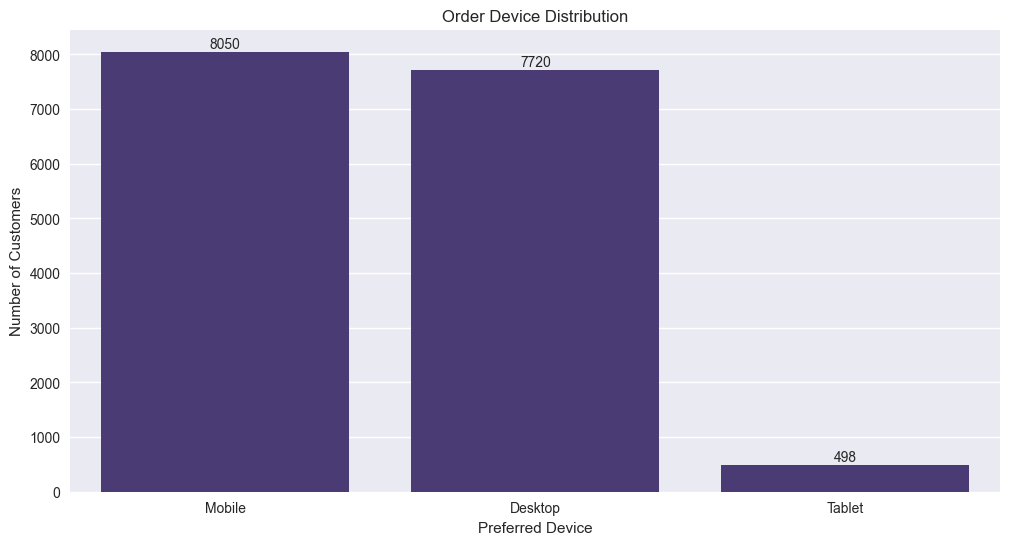

In [50]:
filtered_df = df[df["preferred_device_ord"] != "No purchase"]

order = filtered_df["preferred_device_ord"].value_counts().index

ax = sns.countplot(
    x="preferred_device_ord",
    data=filtered_df,
    order=order
)

plt.title("Order Device Distribution")
plt.xlabel("Preferred Device")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [51]:
df["has_abandoned_cart"] = df["has_abandoned_cart"].map({
    0: "No",
    1: "Yes"
})

## Cart Abandonment

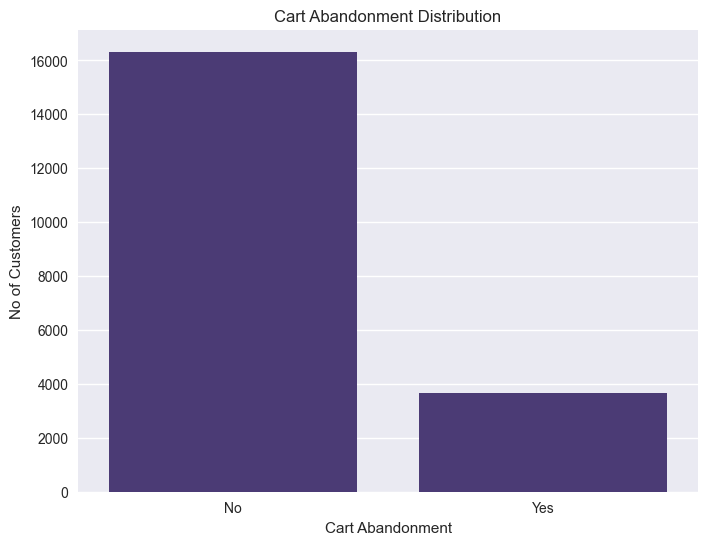

In [52]:
plt.figure(figsize=(8,6))
sns.countplot(x="has_abandoned_cart", data=df)
plt.ylabel("No of Customers")
plt.xlabel("Cart Abandonment")
plt.title("Cart Abandonment Distribution")
plt.show()

In [53]:
df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.strftime('%b')

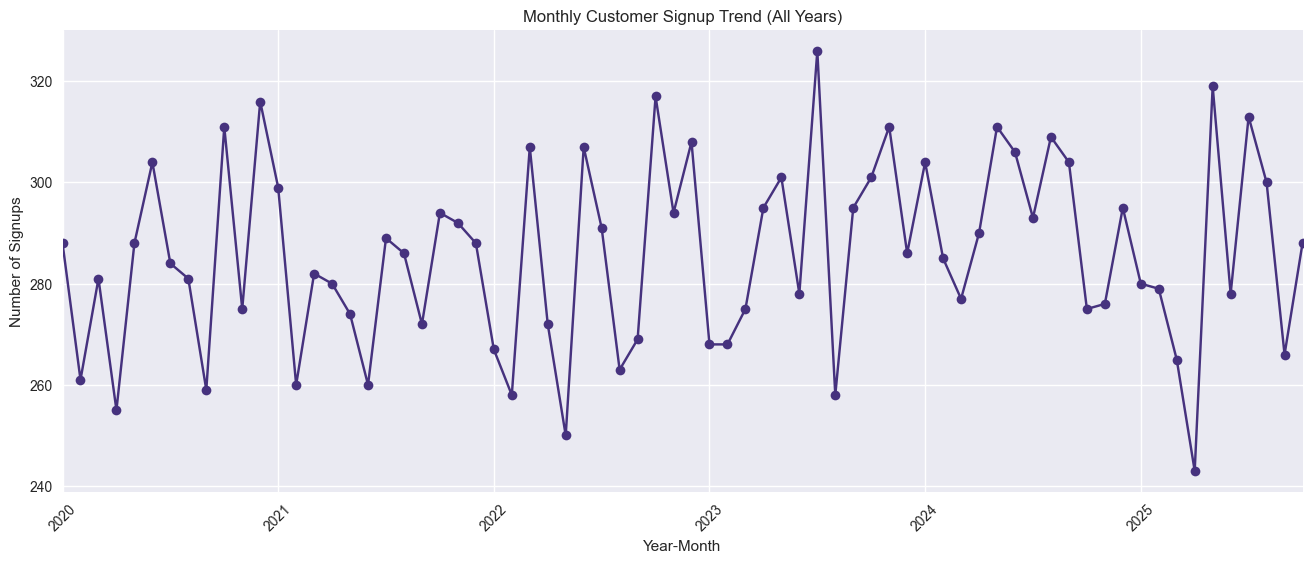

In [54]:
signup_trend = df.groupby(df['signup_date'].dt.to_period('M')).size()

signup_trend.plot(figsize=(16,6), marker='o')

plt.title("Monthly Customer Signup Trend (All Years)")
plt.xlabel("Year-Month")
plt.ylabel("Number of Signups")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## Revenue Time Series Analysis

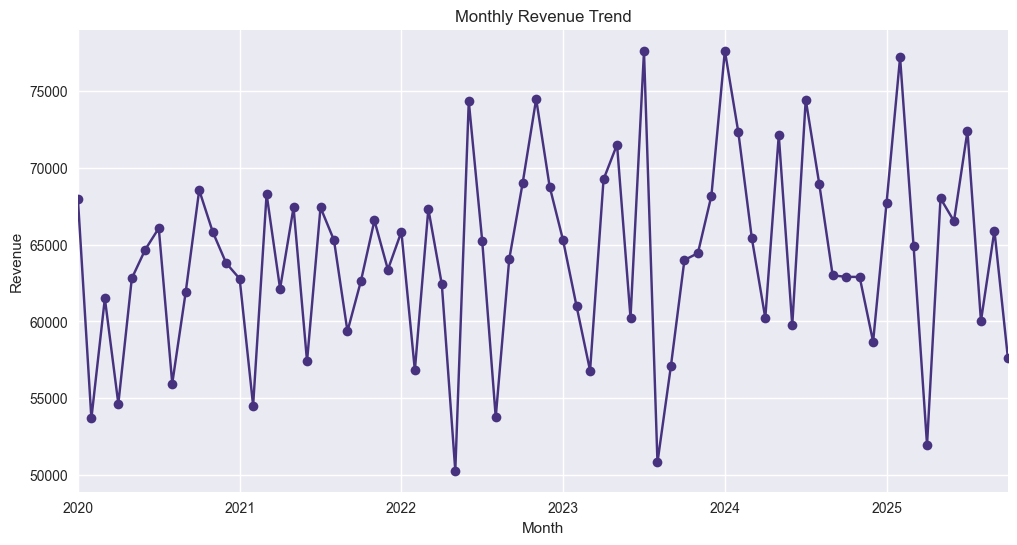

In [55]:
# =========================
# REVENUE TIME SERIES
# =========================

monthly_revenue = df.groupby(
    df['signup_date'].dt.to_period('M')
)['total_spend_usd'].sum()

monthly_revenue.plot(
    kind='line',
    figsize=(12,6),
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

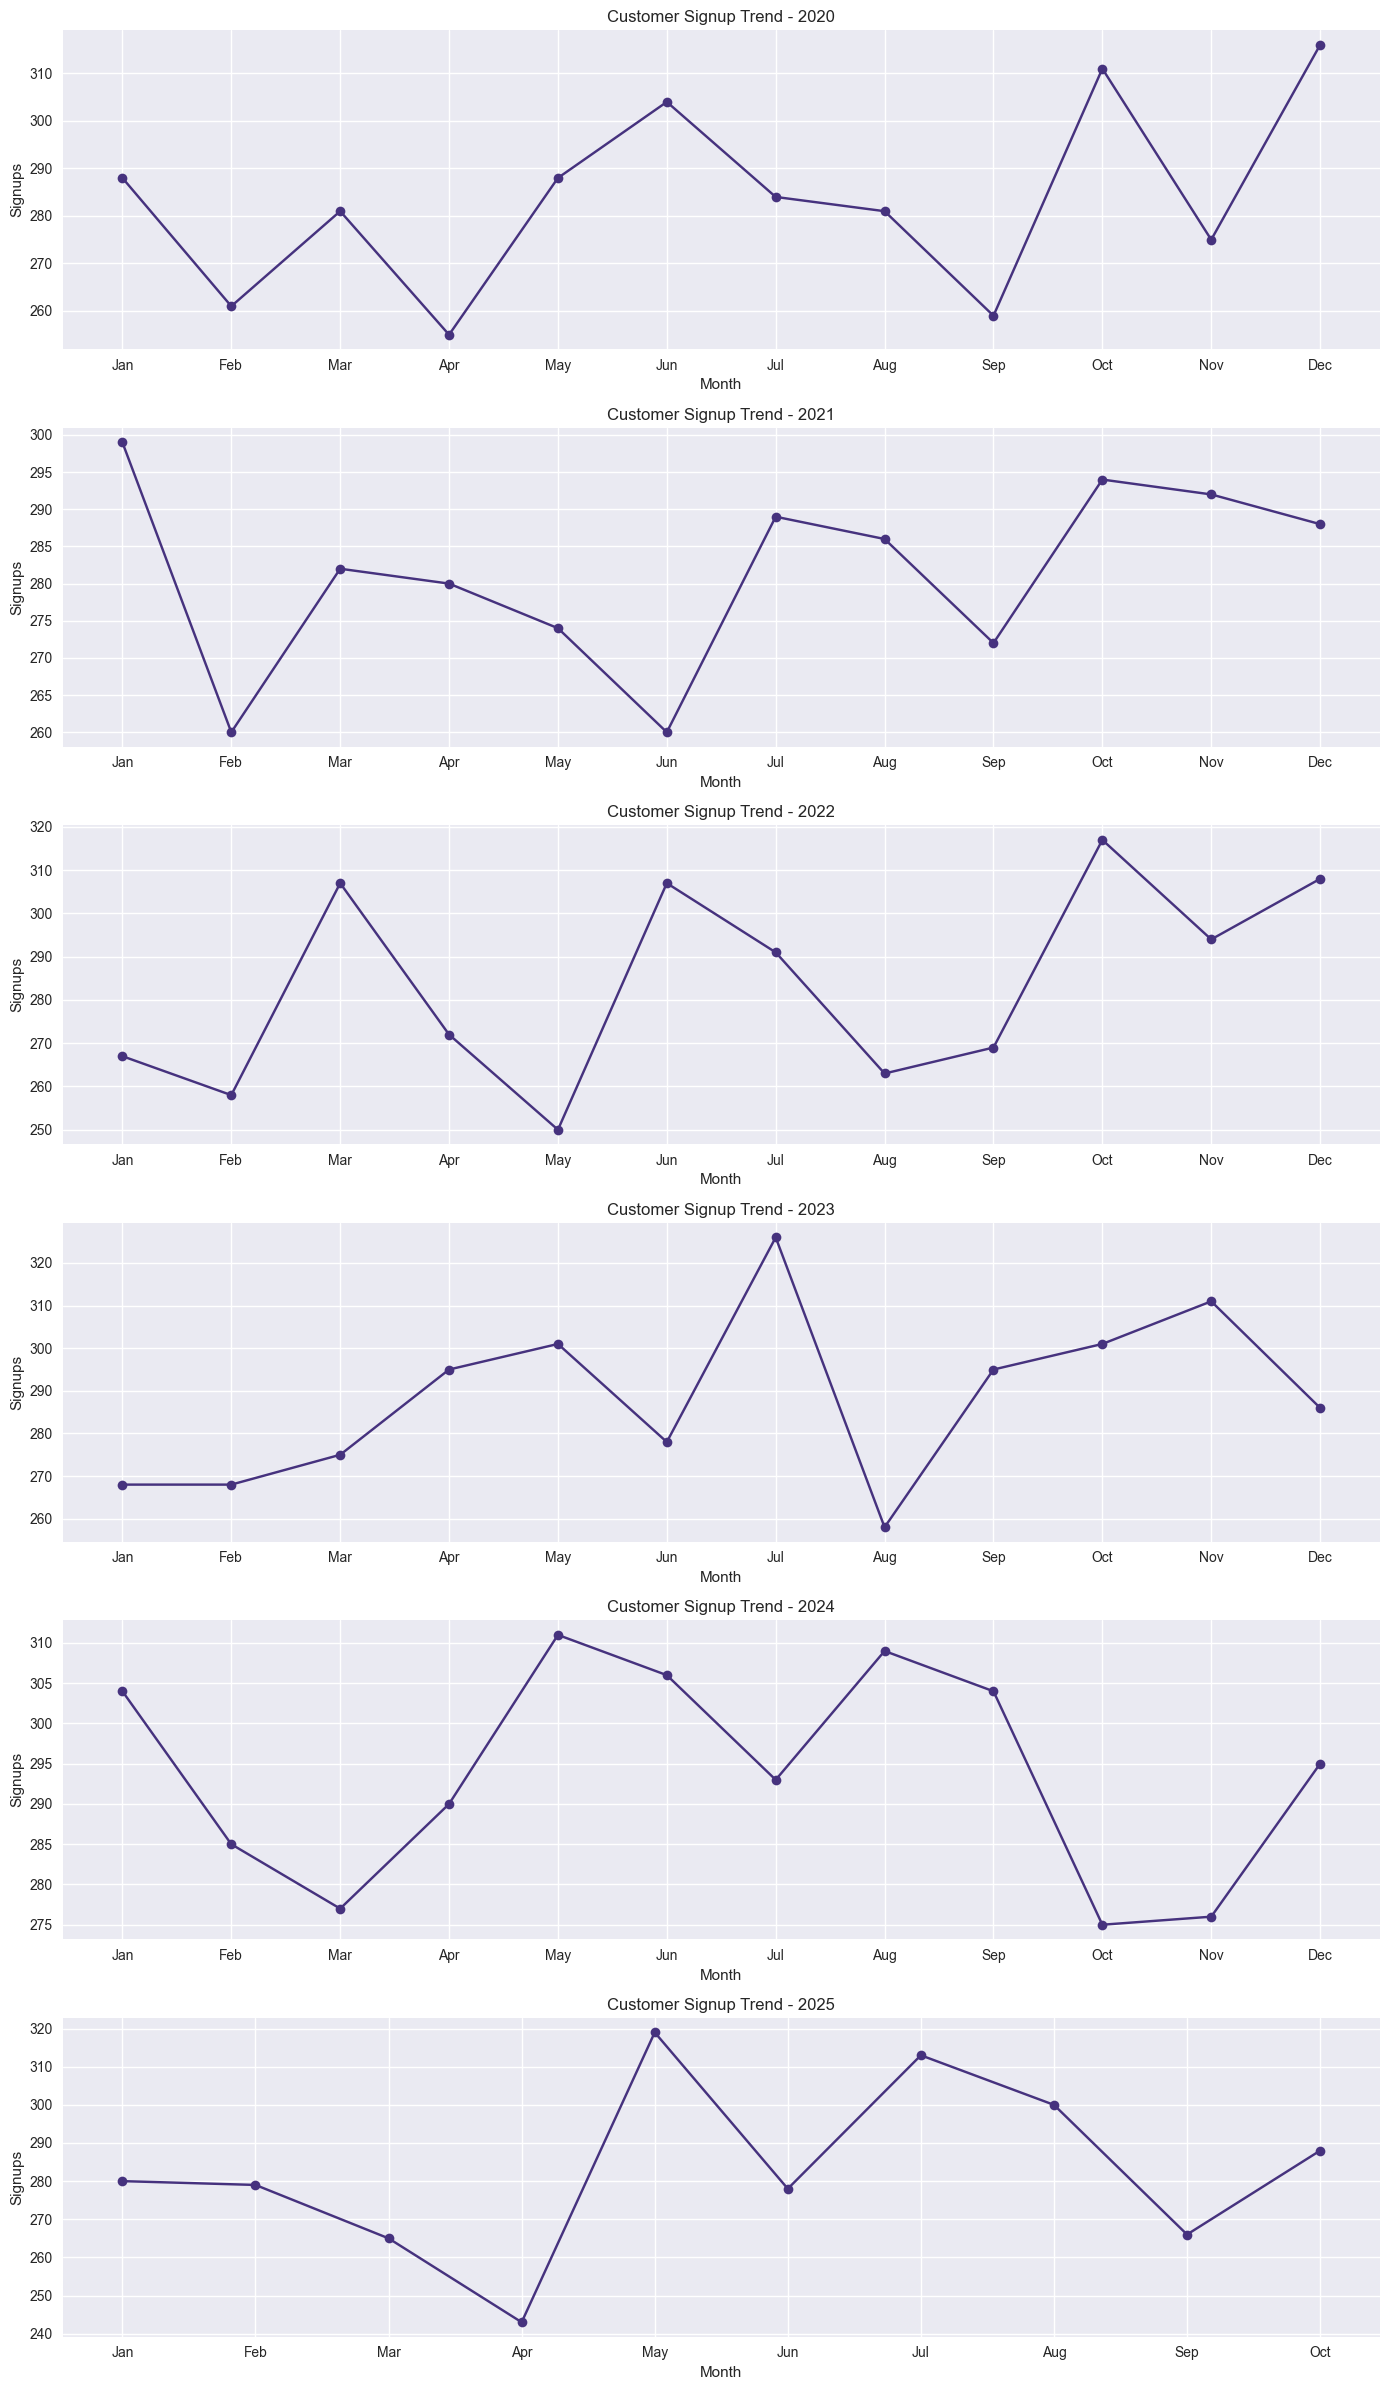

In [56]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

years = sorted(df['signup_year'].unique())

fig, axes = plt.subplots(len(years), 1, figsize=(14, 4*len(years)))

for i, year in enumerate(years):
    
    yearly_data = df[df['signup_year'] == year]
    
    monthly_counts = yearly_data['signup_month'].value_counts()
    monthly_counts = monthly_counts.reindex(month_order)
    
    axes[i].plot(month_order, monthly_counts, marker='o')
    axes[i].set_title(f"Customer Signup Trend - {year}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Signups")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## Discount vs Total Orders

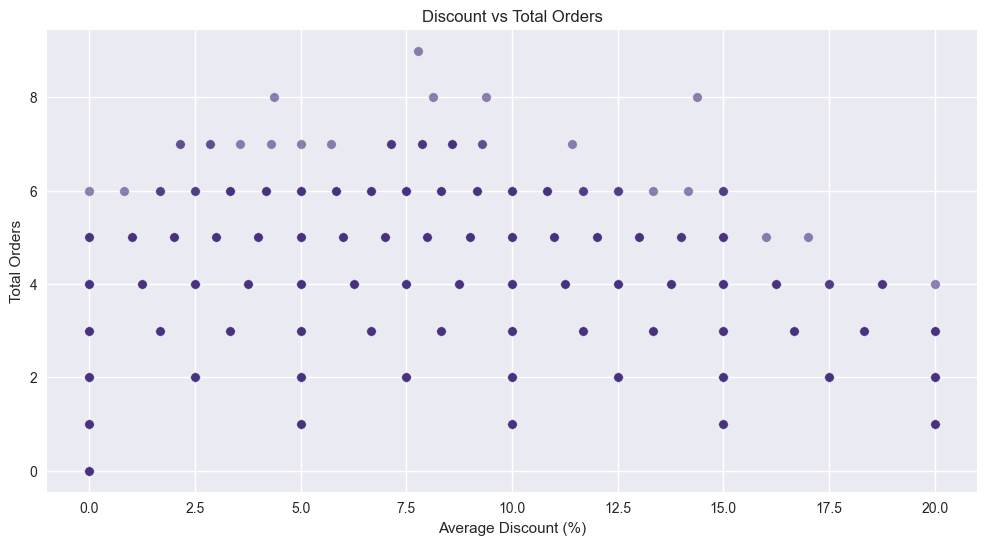

In [57]:
sns.scatterplot(
    data=df,
    x='avg_discount_pct',
    y='total_orders',
    alpha=0.6
)

plt.title("Discount vs Total Orders")
plt.xlabel("Average Discount (%)")
plt.ylabel("Total Orders")
plt.show()

In [58]:
df[['avg_discount_pct', 'total_orders']].corr()

,avg_discount_pct,total_orders
avg_discount_pct,1.000000,0.289797
total_orders,0.289797,1.000000


#### Here Not  Strong Relation

In [59]:
df.head()

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer,customer_segment,rating_status,signup_year,signup_month
0,1,Jennifer Salinas,nicholas59@example.org,Japan,71,55+,2020-09-04,True,2,115.39,...,email,2022-03-18 01:58:29,2025-06-25 14:09:53,No,low,1,Buyer,Rated,2020,Sep
1,2,Phillip Ramos,christinarubio@example.com,India,26,25-34,2020-04-05,False,2,68.52,...,organic,2021-06-09 11:10:13,2025-01-02 01:01:29,No,low,1,Buyer,No Rating Given,2020,Apr
2,3,Dawn Fowler,jessica03@example.org,Brazil,21,18-24,2023-08-31,True,1,66.72,...,direct,2020-07-04 06:53:11,2025-08-28 11:01:14,No,low,0,Buyer,No Rating Given,2023,Aug
3,4,Mario Butler,paula27@example.org,France,63,55+,2022-06-30,True,2,279.86,...,direct,2020-09-29 02:46:16,2024-11-27 23:38:49,No,medium,1,Buyer,No Rating Given,2022,Jun
4,5,Amber Brown,kevin85@example.net,Brazil,19,18-24,2022-07-22,True,3,271.29,...,organic,2020-01-31 02:47:48,2025-01-29 23:45:28,No,medium,1,Buyer,Rated,2022,Jul


In [60]:
df.loc[df["clv_tier"] == "vip", "clv_tier"] = "high"

In [61]:
df["clv_tier"] = df["clv_tier"].str.title()

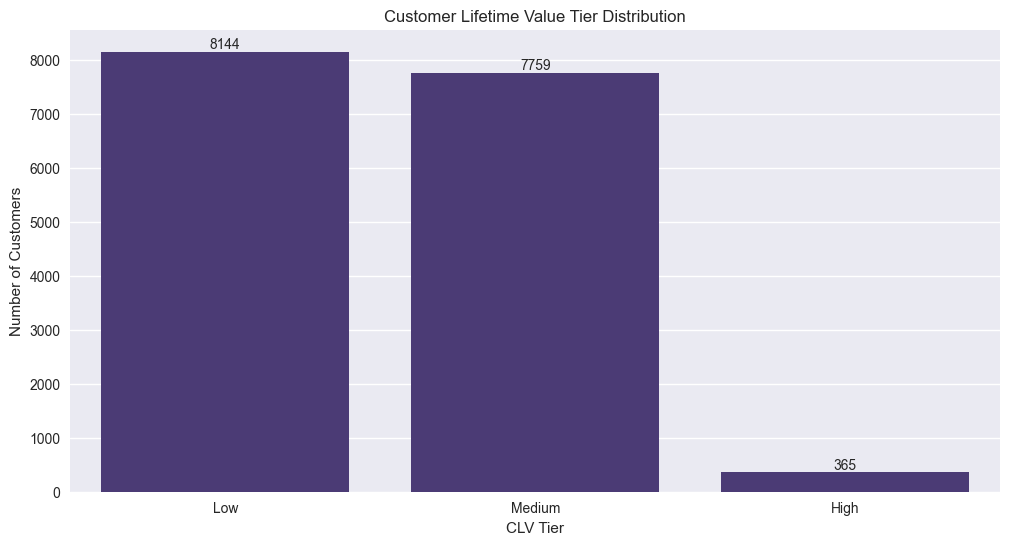

In [62]:
filtered_df = df[df["clv_tier"] != "No_Purchase"]

order = filtered_df["clv_tier"].value_counts().index

ax = sns.countplot(
    data=filtered_df,
    x='clv_tier',
    order=order
)

plt.title("Customer Lifetime Value Tier Distribution")
plt.xlabel("CLV Tier")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

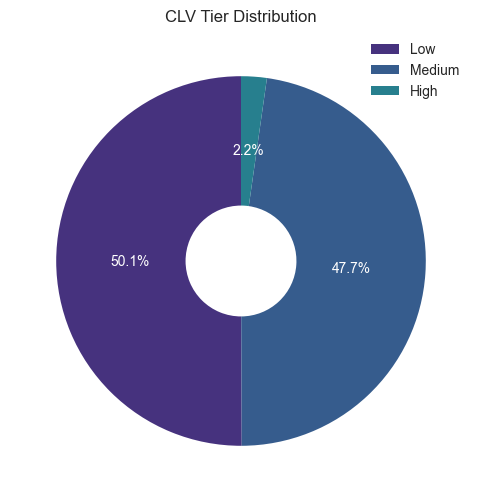

In [63]:
clv_counts = df[df["clv_tier"] != "No_Purchase"]["clv_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    clv_counts,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.7),
    textprops={"color":"white"}
)

plt.legend(clv_counts.index)
plt.title("CLV Tier Distribution")

plt.show()

In [64]:
df["is_repeat_customer"] = df["is_repeat_customer"].map({
    0: "No",
    1: "Yes"
})

In [65]:
df["is_repeat_customer"].value_counts()

is_repeat_customer
Yes    10045
No      9955
Name: count, dtype: int64

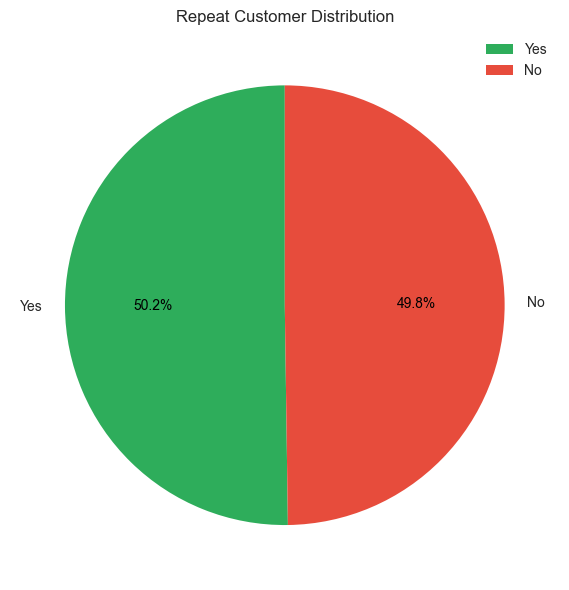

In [66]:
repeat_counts = df['is_repeat_customer'].value_counts()

plt.figure(figsize=(6,6))

wedges, texts, autotexts = plt.pie(
    repeat_counts,
    labels=repeat_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2EAD5B', '#E74C3C']
)

for autotext in autotexts:
    autotext.set_color('black')

plt.title("Repeat Customer Distribution")

plt.legend()

plt.tight_layout()
plt.show()

In [67]:
df.head()

,customer_id,name,email,country,age,age_group,signup_date,marketing_opt_in,total_orders,total_spend_usd,...,preferred_source_sess,first_session_date,last_session_date,has_abandoned_cart,clv_tier,is_repeat_customer,customer_segment,rating_status,signup_year,signup_month
0,1,Jennifer Salinas,nicholas59@example.org,Japan,71,55+,2020-09-04,True,2,115.39,...,email,2022-03-18 01:58:29,2025-06-25 14:09:53,No,Low,Yes,Buyer,Rated,2020,Sep
1,2,Phillip Ramos,christinarubio@example.com,India,26,25-34,2020-04-05,False,2,68.52,...,organic,2021-06-09 11:10:13,2025-01-02 01:01:29,No,Low,Yes,Buyer,No Rating Given,2020,Apr
2,3,Dawn Fowler,jessica03@example.org,Brazil,21,18-24,2023-08-31,True,1,66.72,...,direct,2020-07-04 06:53:11,2025-08-28 11:01:14,No,Low,No,Buyer,No Rating Given,2023,Aug
3,4,Mario Butler,paula27@example.org,France,63,55+,2022-06-30,True,2,279.86,...,direct,2020-09-29 02:46:16,2024-11-27 23:38:49,No,Medium,Yes,Buyer,No Rating Given,2022,Jun
4,5,Amber Brown,kevin85@example.net,Brazil,19,18-24,2022-07-22,True,3,271.29,...,organic,2020-01-31 02:47:48,2025-01-29 23:45:28,No,Medium,Yes,Buyer,Rated,2022,Jul


In [68]:
df["preferred_source_sess"].value_counts()

preferred_source_sess
organic       8598
direct        7893
email         1232
paid           992
social         831
referral       399
No Session      55
Name: count, dtype: int64

In [69]:
# df["preferred_source_sess"] = df["preferred_source_sess"].fillna("").str.title()

In [70]:
df["preferred_source_sess"] = df["preferred_source_sess"].str.title()

## Preferred Session Source Distribution

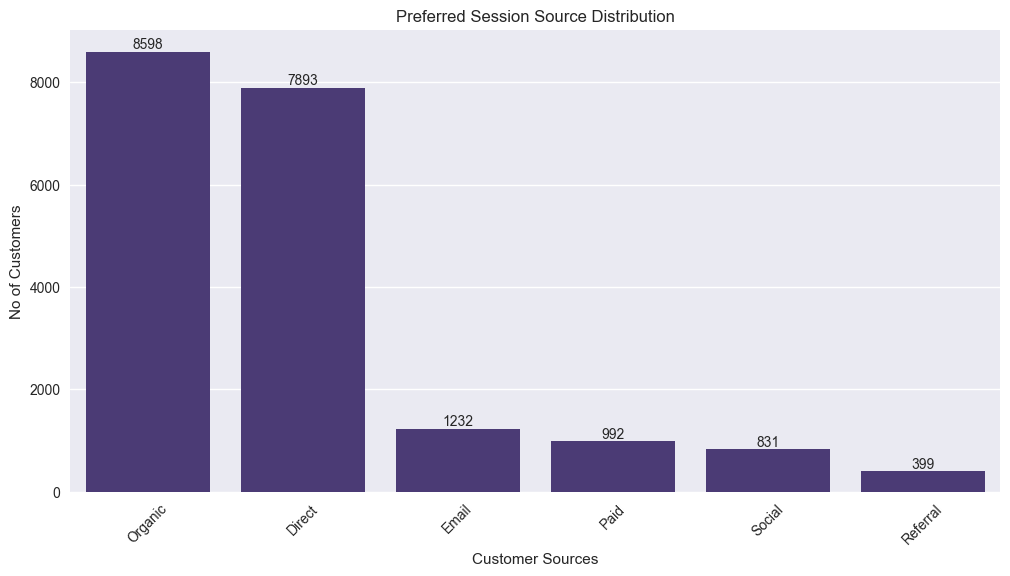

In [71]:
filtered_df = df[df["preferred_source_sess"] != "No Session"]

ax = sns.countplot(
    data=filtered_df,
    x="preferred_source_sess",
    order=filtered_df["preferred_source_sess"].value_counts().index
)

plt.title("Preferred Session Source Distribution")
plt.xlabel("Customer Sources")
plt.ylabel("No of Customers")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            20000 non-null  int64         
 1   name                   20000 non-null  object        
 2   email                  20000 non-null  object        
 3   country                20000 non-null  object        
 4   age                    20000 non-null  int64         
 5   age_group              20000 non-null  object        
 6   signup_date            20000 non-null  datetime64[ns]
 7   marketing_opt_in       20000 non-null  bool          
 8   total_orders           20000 non-null  int64         
 9   total_spend_usd        20000 non-null  float64       
 10  avg_order_value        20000 non-null  float64       
 11  avg_discount_pct       20000 non-null  float64       
 12  first_order_date       16268 non-null  datetime64[ns]
 13  l

## Customer Loyalty Distribution

In [73]:
filtered_df = df[
    df["first_session_date"].notna() &
    df["last_session_date"].notna()
]

In [74]:
filtered_df["active_days"] = (
    filtered_df["last_session_date"] - filtered_df["first_session_date"]
).dt.days

C:\Users\Hiren Vaghela\AppData\Local\Temp\ipykernel_11600\165008349.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [75]:
filtered_df["active_days"].describe()

count    19945.000000
mean      1429.371622
std        475.843676
min          0.000000
25%       1175.000000
50%       1537.000000
75%       1792.000000
max       2129.000000
Name: active_days, dtype: float64

In [76]:
def activity_group(days):
    if days <= 500:
        return "Low Active"
    elif days <= 1500:
        return "Moderately Active"
    else:
        return "Highly Active"

filtered_df["activity_status"] = filtered_df["active_days"].apply(activity_group)

C:\Users\Hiren Vaghela\AppData\Local\Temp\ipykernel_11600\125276341.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



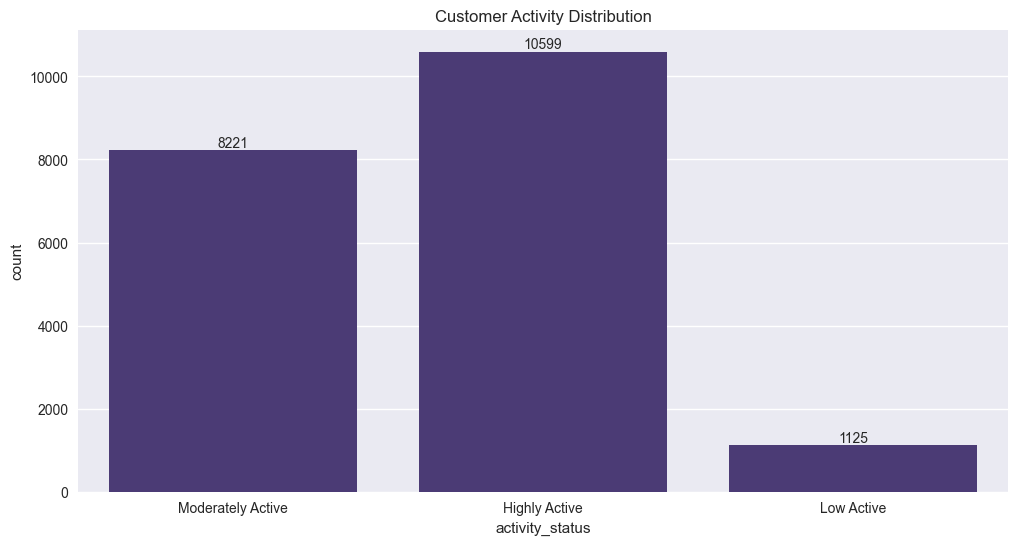

In [77]:
ax = sns.countplot(data=filtered_df, x="activity_status")

plt.title("Customer Activity Distribution")

for container in ax.containers:
    ax.bar_label(container)


plt.show()

In [78]:
def loyalty_status(row):
    
    if (
        row["total_orders"] >= 4 and
        row["total_spend_usd"] >= 500 and
        row["active_days"] >= 1500
    ):
        return "High Loyalty"
    
    elif (
        row["total_orders"] >= 2 and
        row["total_spend_usd"] >= 150 and
        row["active_days"] >= 1000
    ):
        return "Medium Loyalty"
    
    else:
        return "Low Loyalty"


filtered_df["customer_loyalty"] = filtered_df.apply(
    loyalty_status,
    axis=1
)

C:\Users\Hiren Vaghela\AppData\Local\Temp\ipykernel_11600\755511904.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [79]:
filtered_df["customer_loyalty"].value_counts()

customer_loyalty
Low Loyalty       12685
Medium Loyalty     6573
High Loyalty        687
Name: count, dtype: int64

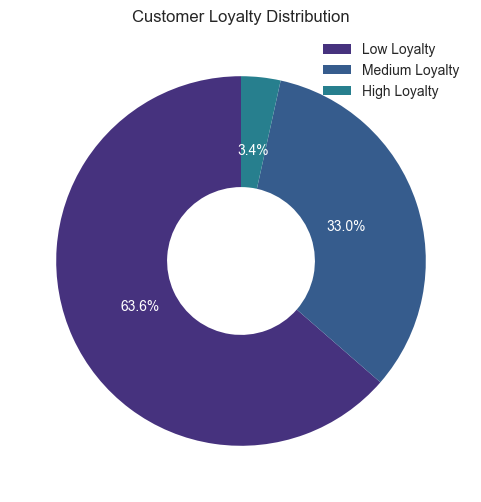

In [80]:
loyalty_counts = filtered_df["customer_loyalty"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    loyalty_counts,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.6),
    textprops={"color":"white"}
)

plt.legend(loyalty_counts.index)
plt.title("Customer Loyalty Distribution")

plt.show()

## Customer Behavior Correlation

In [81]:
heatmap_cols = [
    'total_orders',
    'total_spend_usd',
    'avg_discount_pct',
    'total_sessions',
    'avg_rating_given'
]

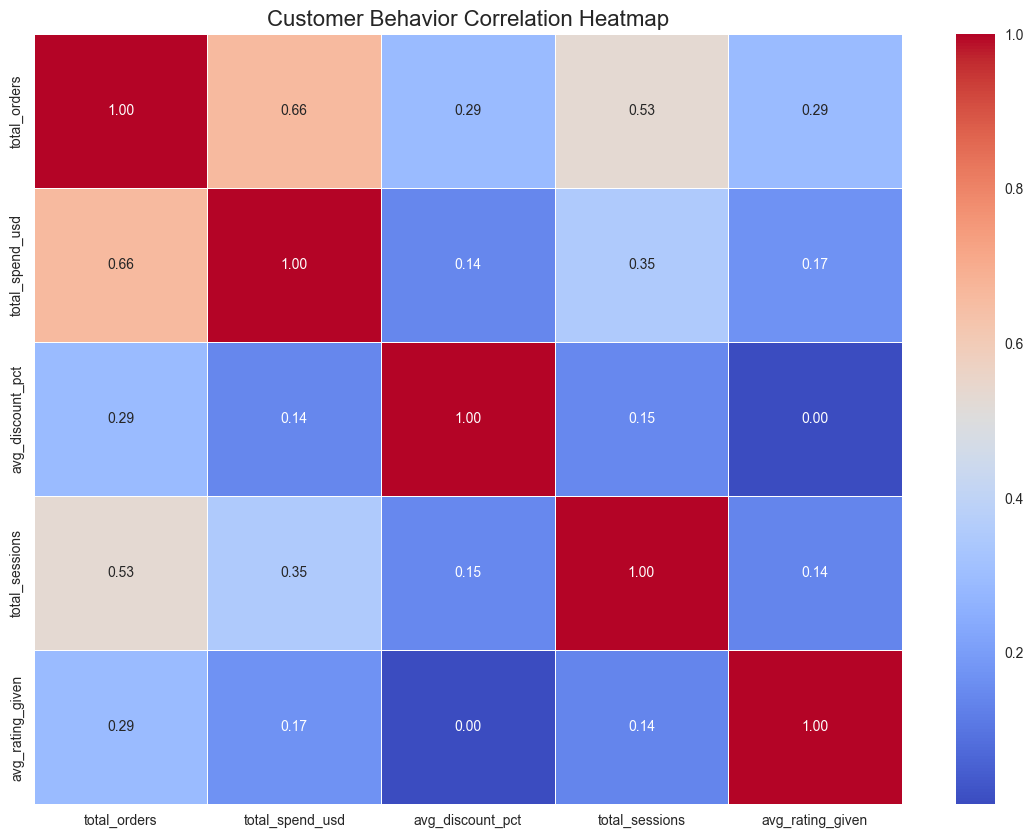

In [82]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df[heatmap_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Customer Behavior Correlation Heatmap", fontsize=16)
plt.show()